In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import numpy as np

In [ ]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
BASE_DIR = "/content/drive/My Drive/DL_Data/Results/"

cnn_tab_path = os.path.join(BASE_DIR, "cnntabular.csv")
cnn_tab_df = pd.read_csv(cnn_tab_path)

cnn_only_path = os.path.join(BASE_DIR, "cnn.csv")
cnn_df = pd.read_csv(cnn_only_path)


# cnn_img_path = os.path.join(BASE_DIR, "CNN:Image_results.csv")
# cnn_img_df = read_csv(cnn_img_path)
# # cnn_img_df = os.path.join(BASE_DIR, "cnn_img.csv")

In [ ]:
print(cnn_df.columns)
print(cnn_tab_df.columns)

Index(['image_name', 'name', 'pred', 'target', 'residual', 'abs_error'], dtype='object')
Index(['pred', 'target', 'name', 'residual', 'abs_error'], dtype='object')


In [ ]:
TABULAR_COLUMS = ['State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']
CATEGORICAL_COLS = ['State', 'Species']
NUMERIC_COLS = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

TARGET_NAMES = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]

# Performance analysis on the test set

In [ ]:
from sklearn.metrics import r2_score
from typing import List
import numpy as np

TARGET_WEIGHTS = { # I took this from the kaggle competition values
    'Dry_Total_g':  0.4,
    'GDM_g':        0.2,
    'Dry_Green_g':  0.2,
    'Dry_Dead_g':   0.1,
    'Dry_Clover_g': 0.1,
}

def weighted_r2(all_preds: np.ndarray, all_targets: np.ndarray, all_names: np.ndarray) -> float:
    df = pd.DataFrame({
        'pred':        all_preds,
        'target':      all_targets,
        'target_name': all_names
    })

    SSres_total = 0.0
    SStot_total = 0.0
    for target_name, weight in TARGET_WEIGHTS.items():
        subset = df[df['target_name'] == target_name]
        if len(subset) == 0:
            continue

        SSres = weight * ((subset['target'] - subset['pred']) ** 2).sum()
        SStot = weight * ((subset['target'] - subset['target'].mean()) ** 2).sum()

        SSres_total += SSres
        SStot_total += SStot

        # print(f"SSres: {SSres} and SStot: {SStot}")

        # ------- I use the local ssres and sstot just to verify the values, comment out if you need to debug
        # if SSres == 0 and SStot == 0:
        #     r2 = 1
        # else:
        #   r2 = 1 - SSres / SStot

        # print(f"  {target_name:20s} R²: {r2:.4f}  (weight: {weight})")

    weighted_score = 1 - SSres_total / SStot_total
    print(f"  {'Weighted R²':20s}     {weighted_score:.4f}")
    return weighted_score

## We ran the models and save the data - predicted vs actual target

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# ── Unified results dict from your two dataframes ───────────────
results = {
    "CNN only":        cnn_df,
    "CNN + Tabular":   cnn_tab_df,
}

TARGET_WEIGHTS = {
    'Dry_Total_g':  0.4,
    'GDM_g':        0.2,
    'Dry_Green_g':  0.2,
    'Dry_Dead_g':   0.1,
    'Dry_Clover_g': 0.1,
}
TARGET_NAMES = list(TARGET_WEIGHTS.keys())


def get_arrays(df):
    """Extract aligned numpy arrays from a result dataframe."""
    return (
        df["pred"].values,
        df["target"].values,
        np.array(df["name"].values),
    )

In [ ]:

# ────────────────────────────────────────────────────────────────
# 1. Predicted vs Actual
# ────────────────────────────────────────────────────────────────
def plot_predicted_vs_actual(results: dict, figsize=(20, 8)):
    """
    Scatter plot of predicted vs actual per target and model.
    Subplot title shows per-target R².
    Row label shows global weighted R².
    """
    n_models  = len(results)
    n_targets = len(TARGET_NAMES)

    fig, axes = plt.subplots(n_models, n_targets, figsize=figsize)
    if n_models == 1:
        axes = axes[np.newaxis, :]

    for row_idx, (model_name, df) in enumerate(results.items()):
        preds, targets, target_names = get_arrays(df)
        w_r2 = weighted_r2(preds, targets, target_names)

        for col_idx, target_name in enumerate(TARGET_NAMES):
            ax   = axes[row_idx, col_idx]
            mask = target_names == target_name

            y_true = targets[mask]
            y_pred = preds[mask]

            ax.scatter(y_true, y_pred, alpha=0.5, s=15, color=f"C{col_idx}")

            # Perfect prediction line
            lo = min(y_true.min(), y_pred.min())
            hi = max(y_true.max(), y_pred.max())
            ax.plot([lo, hi], [lo, hi], color="red", linewidth=1, linestyle="--")

            # Per-target R²
            ss_res = ((y_true - y_pred) ** 2).sum()
            ss_tot = ((y_true - y_true.mean()) ** 2).sum()
            r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0

            ax.set_title(f"{target_name}\nR²={r2:.3f}", fontsize=8)
            ax.set_xlabel("Actual",    fontsize=7)
            ax.set_ylabel("Predicted", fontsize=7)
            ax.tick_params(labelsize=7)

        # Row label
        axes[row_idx, 0].annotate(
            f"{model_name}\nW-R²={w_r2:.3f}",
            xy=(-0.38, 0.5), xycoords="axes fraction",
            fontsize=9, fontweight="bold", rotation=90, va="center"
        )

    plt.suptitle("Predicted vs Actual — per target", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("predicted_vs_actual.png", bbox_inches="tight", dpi=150)
    plt.show()

In [ ]:
def plot_r2_bar_chart(results: dict, figsize=(13, 6)):
    """
    Grouped bar chart of weighted R² per target for each model.
    Uses weighted_r2 logic applied per-target individually.
    """
    records = []

    for model_name, df in results.items():
        preds, targets, target_names = get_arrays(df)
        df_tmp = pd.DataFrame({"pred": preds, "target": targets, "name": target_names})

        for target_name, weight in TARGET_WEIGHTS.items():
            subset = df_tmp[df_tmp["name"] == target_name]
            if len(subset) == 0:
                continue
            SSres = weight * ((subset["target"] - subset["pred"]) ** 2).sum()
            SStot = weight * ((subset["target"] - subset["target"].mean()) ** 2).sum()
            r2    = min((1 - SSres / SStot) if SStot > 0 else 1.0, 1.0)
            records.append({"model": model_name, "target_name": target_name, "r2": r2})

    plot_df  = pd.DataFrame(records)
    n_models = len(results)
    x        = np.arange(len(TARGET_NAMES))
    width    = 0.8 / n_models

    fig, ax = plt.subplots(figsize=figsize)

    for i, model_name in enumerate(results.keys()):
        model_df  = plot_df[plot_df["model"] == model_name]
        r2_values = [
            model_df[model_df["target_name"] == t]["r2"].values[0]
            for t in TARGET_NAMES
        ]
        offset = (i - n_models / 2 + 0.5) * width
        bars   = ax.bar(x + offset, r2_values, width=width,
                        label=model_name, color=f"C{i}", alpha=0.85)

        for bar, val in zip(bars, r2_values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=8
            )

    ax.axhline(y=0, color="red",  linewidth=1,   linestyle="--", label="baseline")
    ax.axhline(y=1, color="gray", linewidth=0.8, linestyle=":",  label="perfect")
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_NAMES, fontsize=9, rotation=15)
    ax.set_ylabel("Weighted R² (per target)", fontsize=11)
    ax.set_xlabel("Biomass target",            fontsize=11)
    ax.set_title("Weighted R² per target — model comparison", fontsize=13)
    ax.set_ylim(bottom=min(plot_df["r2"].min() - 0.1, -0.15), top=1.1)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("r2_bar_chart.png", bbox_inches="tight", dpi=150)
    plt.show()

In [ ]:
def plot_r2_comparison_histogram(results: dict, figsize=(10, 6)):
    """
    Side-by-side bars of regular R² vs weighted R² per model.
    Shows whether your model is aligned with the competition metric.
    """
    records = []

    for model_name, df in results.items():
        preds, targets, target_names = get_arrays(df)
        regular_r2 = min(r2_score(targets, preds), 1.0)
        w_r2       = min(weighted_r2(preds, targets, target_names), 1.0)
        records.append({
            "model":       model_name,
            "Regular R²":  regular_r2,
            "Weighted R²": w_r2,
        })

    plot_df   = pd.DataFrame(records)
    n_models  = len(records)
    n_metrics = 2
    x         = np.arange(n_models)
    width     = 0.35
    colors    = ["steelblue", "darkorange"]

    fig, ax = plt.subplots(figsize=figsize)

    for i, (metric, color) in enumerate(zip(["Regular R²", "Weighted R²"], colors)):
        values = plot_df[metric].values
        offset = (i - n_metrics / 2 + 0.5) * width
        bars   = ax.bar(x + offset, values, width=width,
                        label=metric, color=color, alpha=0.85)
        for bar, val in zip(bars, values):
            y_pos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.04
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    ax.axhline(y=0, color="red",  linewidth=1,   linestyle="--", label="baseline")
    ax.axhline(y=1, color="gray", linewidth=0.8, linestyle=":",  label="perfect")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["model"], fontsize=11)
    ax.set_ylabel("R² score", fontsize=11)
    ax.set_xlabel("Model",    fontsize=11)
    ax.set_title("Regular R² vs Weighted R² — all targets pooled", fontsize=13)
    ax.set_ylim(
        bottom=min(plot_df[["Regular R²", "Weighted R²"]].min().min() - 0.1, -0.2),
        top=1.15
    )
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("r2_comparison.png", bbox_inches="tight", dpi=150)
    plt.show()


In [ ]:
def plot_residuals(results: dict, figsize=(14, 5)):
    """
    Residual plots per model, colored by target name.
    Trend line reveals systematic bias.
    """
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, df) in zip(axes, results.items()):
        preds, targets, target_names = get_arrays(df)
        residuals = targets - preds

        for i, target_name in enumerate(TARGET_NAMES):
            mask = target_names == target_name
            ax.scatter(preds[mask], residuals[mask],
                       alpha=0.5, s=15, color=f"C{i}", label=target_name)

        # Zero line
        ax.axhline(y=0, color="red", linewidth=1, linestyle="--", label="zero residual")

        # Trend line
        z      = np.polyfit(preds, residuals, deg=1)
        x_line = np.linspace(preds.min(), preds.max(), 200)
        ax.plot(x_line, np.poly1d(z)(x_line), color="black",
                linewidth=1.2, linestyle="-", label="trend")

        # Stats + weighted R²
        w_r2 = weighted_r2(preds, targets, target_names)
        ax.text(
            0.02, 0.97,
            f"mean res: {residuals.mean():.2f}\nstd res:  {residuals.std():.2f}",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )
        ax.set_title(f"{model_name}\nW-R²={w_r2:.3f}", fontsize=10)
        ax.set_xlabel("Predicted value",               fontsize=9)
        ax.set_ylabel("Residual (Actual − Predicted)", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=7, loc="upper right")

    plt.suptitle("Residual Analysis — per model", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("residual_plots.png", bbox_inches="tight", dpi=150)
    plt.show()


  Weighted R²              -0.9897
  Weighted R²              0.4364


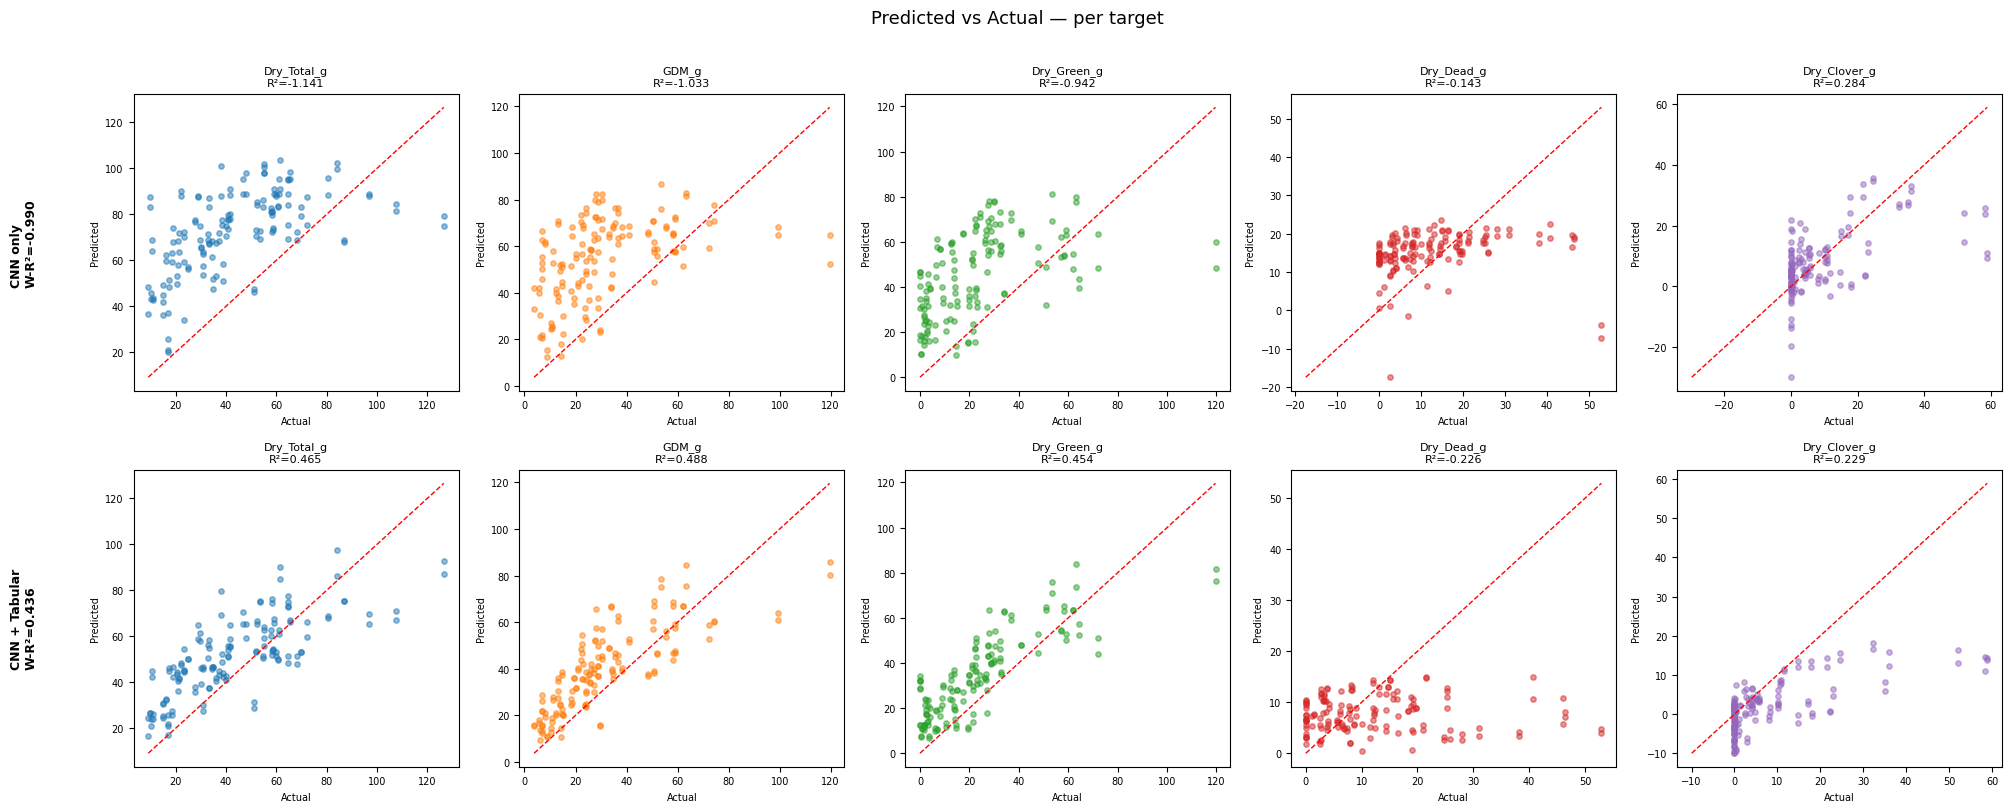

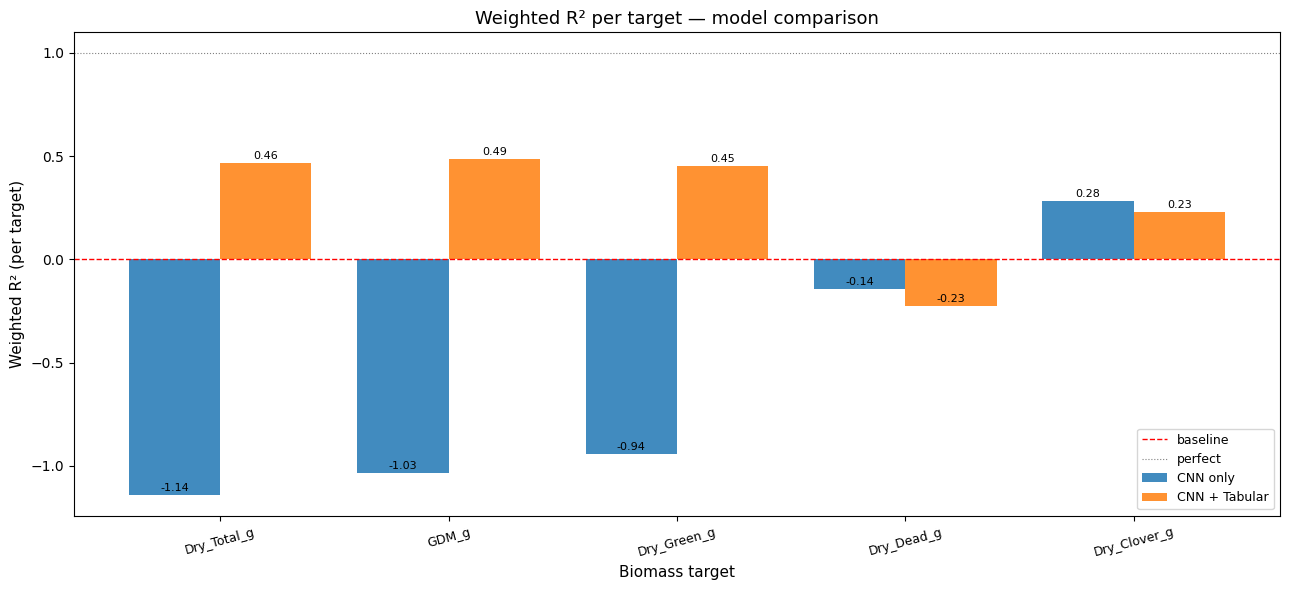

  Weighted R²              -0.9897
  Weighted R²              0.4364


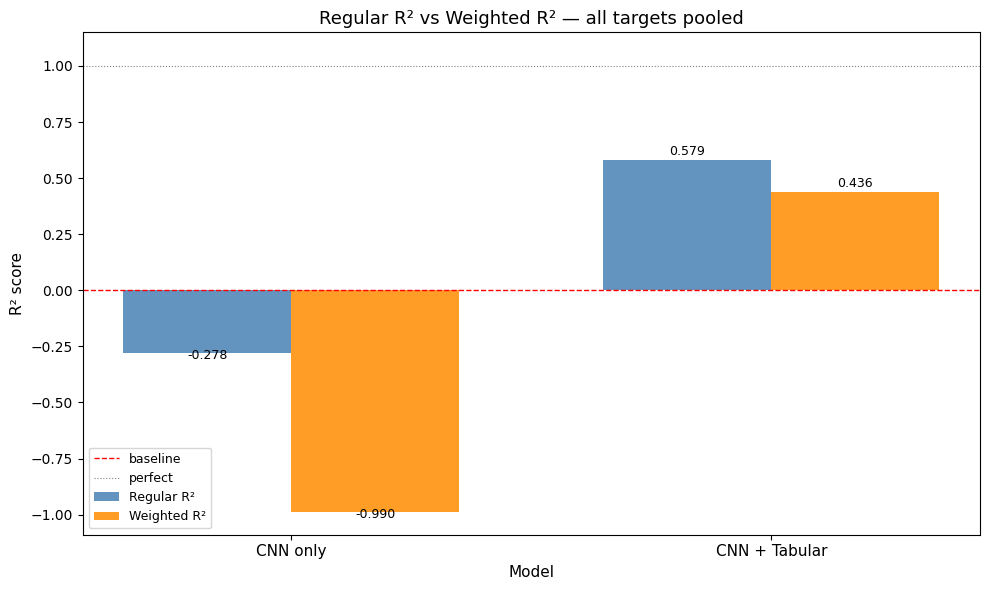

  Weighted R²              -0.9897
  Weighted R²              0.4364


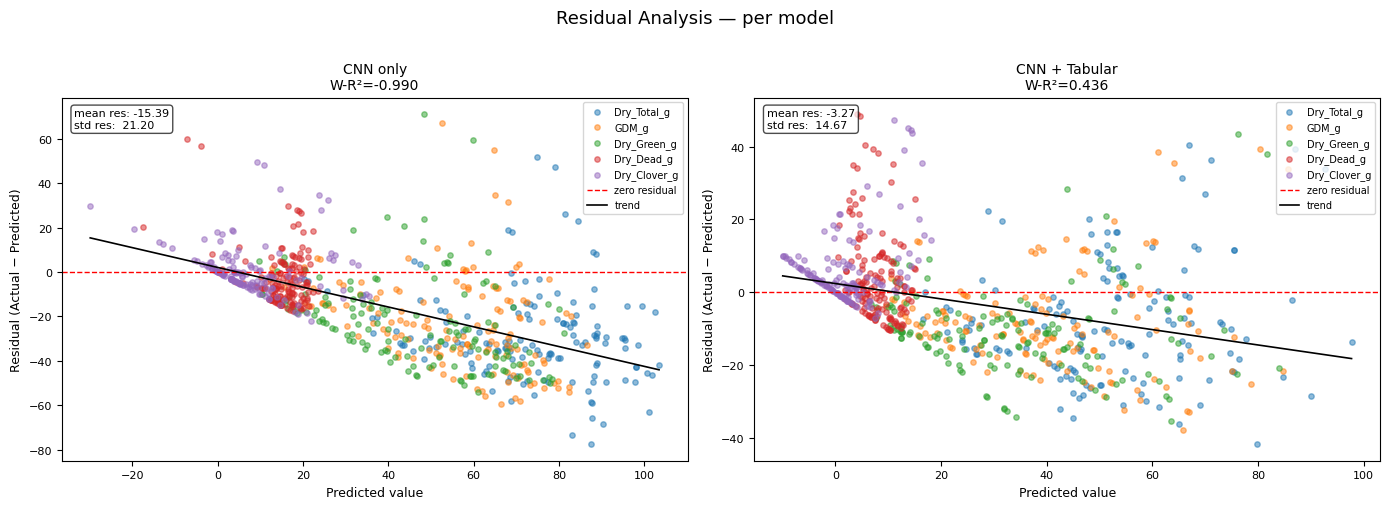

In [ ]:
plot_predicted_vs_actual(results)
plot_r2_bar_chart(results)
plot_r2_comparison_histogram(results)
plot_residuals(results)

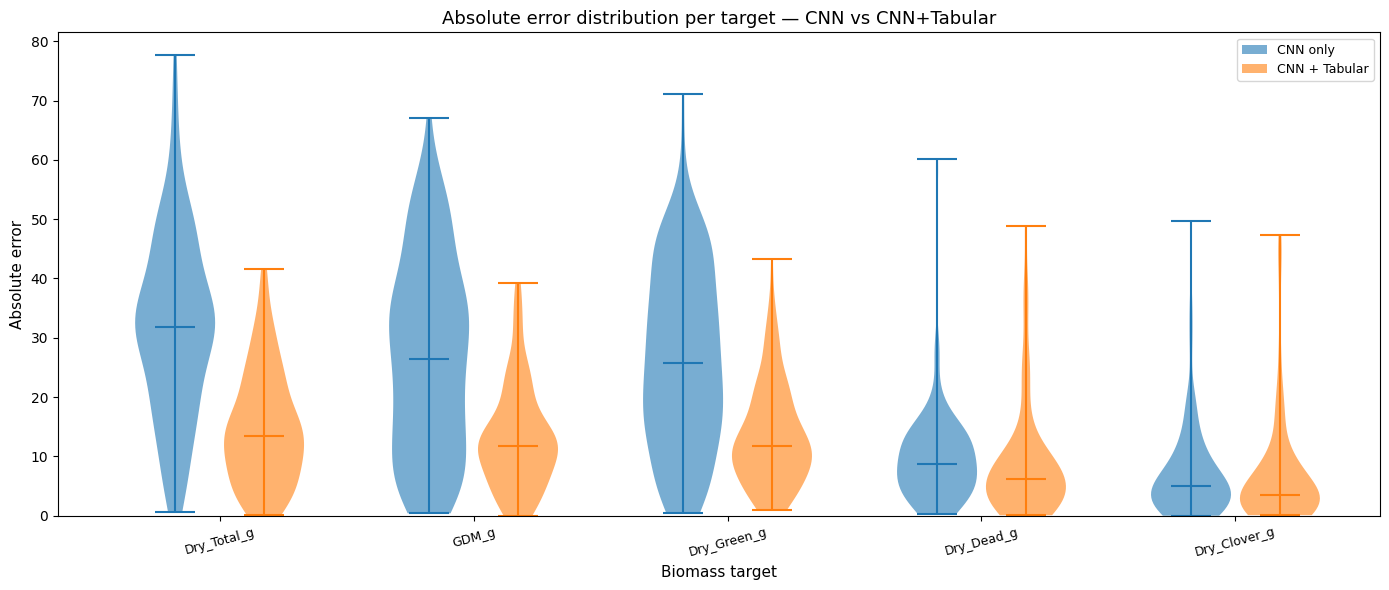

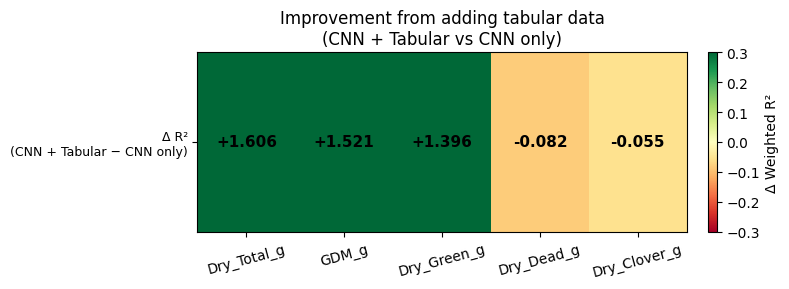

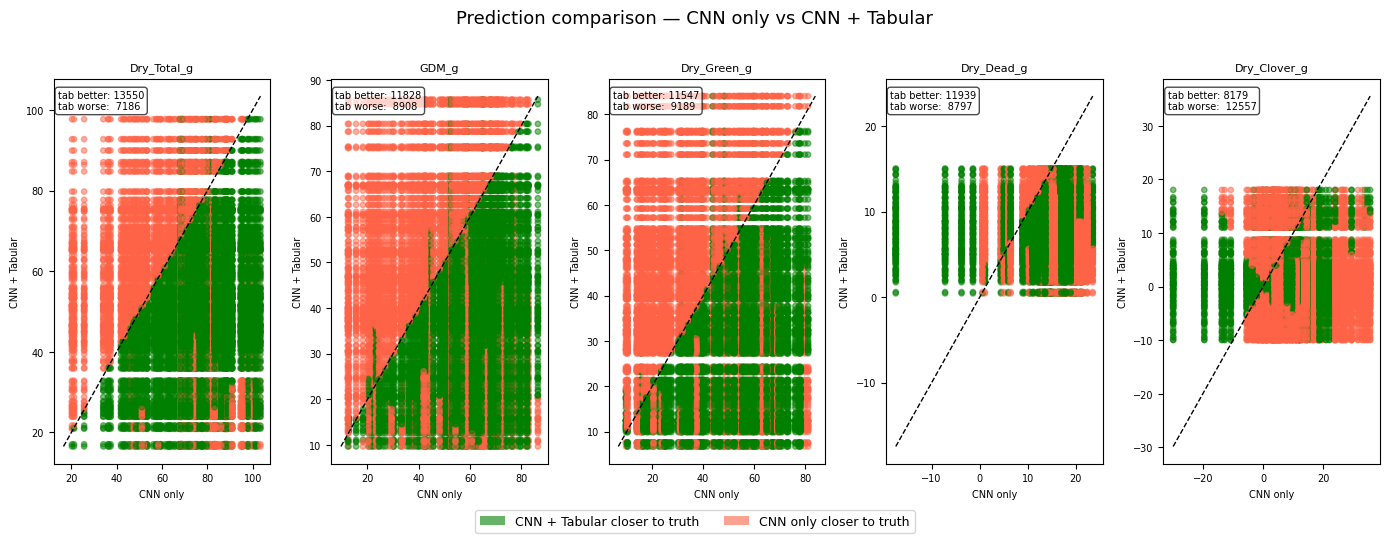

In [ ]:
# ────────────────────────────────────────────────────────────────
# 5. Absolute error — violin plot per target per model
# ────────────────────────────────────────────────────────────────
def plot_error_distribution(results: dict, figsize=(14, 6)):
    """
    Violin plot of absolute error per target for each model.
    Tighter violin = more consistent predictions.
    """
    records = []
    for model_name, df in results.items():
        for _, row in df.iterrows():
            records.append({
                "model":       model_name,
                "target_name": row["name"],
                "abs_error":   row["abs_error"],
            })

    plot_df  = pd.DataFrame(records)
    n_models = len(results)
    x        = np.arange(len(TARGET_NAMES))
    width    = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    # Collect violin positions and data
    for i, model_name in enumerate(results.keys()):
        model_df = plot_df[plot_df["model"] == model_name]
        data     = [
            model_df[model_df["target_name"] == t]["abs_error"].values
            for t in TARGET_NAMES
        ]
        positions = x + (i - n_models / 2 + 0.5) * width

        parts = ax.violinplot(
            data,
            positions  = positions,
            widths     = width * 0.9,
            showmedians = True,
            showextrema = True,
        )
        # Color all parts consistently per model
        for pc in parts["bodies"]:
            pc.set_facecolor(f"C{i}")
            pc.set_alpha(0.6)
        for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
            parts[key].set_color(f"C{i}")

        # Dummy bar for legend
        ax.bar(0, 0, color=f"C{i}", alpha=0.6, label=model_name)

    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_NAMES, fontsize=9, rotation=15)
    ax.set_ylabel("Absolute error", fontsize=11)
    ax.set_xlabel("Biomass target", fontsize=11)
    ax.set_title("Absolute error distribution per target — CNN vs CNN+Tabular", fontsize=13)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("error_distribution.png", bbox_inches="tight", dpi=150)
    plt.show()


# ────────────────────────────────────────────────────────────────
# 6. Improvement heatmap — Δ weighted R² per target
# ────────────────────────────────────────────────────────────────
def plot_improvement_heatmap(results: dict, figsize=(8, 3)):
    """
    Heatmap of Δ weighted R² = CNN+Tabular minus CNN only, per target.
    Green = tabular helped, Red = tabular hurt.
    Reveals which targets benefit most from tabular features.
    """
    assert len(results) == 2, "Heatmap requires exactly 2 models to compare"

    model_names = list(results.keys())
    r2_per_target = {}

    for model_name, df in results.items():
        preds, targets, target_names = get_arrays(df)
        df_tmp = pd.DataFrame({"pred": preds, "target": targets, "name": target_names})
        r2_per_target[model_name] = {}

        for target_name, weight in TARGET_WEIGHTS.items():
            subset = df_tmp[df_tmp["name"] == target_name]
            if len(subset) == 0:
                r2_per_target[model_name][target_name] = 0.0
                continue
            SSres = weight * ((subset["target"] - subset["pred"]) ** 2).sum()
            SStot = weight * ((subset["target"] - subset["target"].mean()) ** 2).sum()
            r2_per_target[model_name][target_name] = (
                (1 - SSres / SStot) if SStot > 0 else 1.0
            )

    # Delta = second model - first model
    delta = np.array([
        r2_per_target[model_names[1]][t] - r2_per_target[model_names[0]][t]
        for t in TARGET_NAMES
    ]).reshape(1, -1)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(delta, cmap="RdYlGn", aspect="auto", vmin=-0.3, vmax=0.3)

    # Labels
    ax.set_xticks(range(len(TARGET_NAMES)))
    ax.set_xticklabels(TARGET_NAMES, fontsize=10, rotation=15)
    ax.set_yticks([0])
    ax.set_yticklabels([f"Δ R²\n({model_names[1]} − {model_names[0]})"], fontsize=9)

    # Value annotations
    for j, target_name in enumerate(TARGET_NAMES):
        val = delta[0, j]
        ax.text(j, 0, f"{val:+.3f}",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="black")

    plt.colorbar(im, ax=ax, label="Δ Weighted R²", fraction=0.02, pad=0.04)
    ax.set_title(f"Improvement from adding tabular data\n({model_names[1]} vs {model_names[0]})",
                 fontsize=12)

    plt.tight_layout()
    plt.savefig("improvement_heatmap.png", bbox_inches="tight", dpi=150)
    plt.show()


# ────────────────────────────────────────────────────────────────
# 7. CNN pred vs CNN+Tabular pred scatter
# ────────────────────────────────────────────────────────────────
def plot_pred_vs_pred(results: dict, figsize=(14, 5)):
    """
    Scatter of CNN predictions vs CNN+Tabular predictions per target.
    Points colored by which model was closer to ground truth.
    Points far from diagonal = cases where tabular data changed prediction.
    """
    assert len(results) == 2, "This plot requires exactly 2 models"

    model_names  = list(results.keys())
    df_a         = results[model_names[0]]   # CNN only
    df_b         = results[model_names[1]]   # CNN + Tabular

    # Align on name since image_name may differ
    df_merged = df_a[["name", "pred", "target"]].merge(
        df_b[["name", "pred", "target"]],
        on     = "name",
        suffixes = ("_a", "_b")
    )

    fig, axes = plt.subplots(1, len(TARGET_NAMES), figsize=figsize, sharey=False)

    for ax, target_name in zip(axes, TARGET_NAMES):
        subset = df_merged[df_merged["name"] == target_name]

        preds_a  = subset["pred_a"].values
        preds_b  = subset["pred_b"].values
        targets  = subset["target_a"].values

        err_a    = np.abs(targets - preds_a)
        err_b    = np.abs(targets - preds_b)

        # Color: green = CNN+Tabular closer, red = CNN only closer
        colors   = np.where(err_b < err_a, "green", "tomato")
        n_better = (err_b < err_a).sum()
        n_worse  = (err_b >= err_a).sum()

        ax.scatter(preds_a, preds_b, c=colors, alpha=0.5, s=15)

        # Diagonal — if on the line, both models agree
        lo = min(preds_a.min(), preds_b.min())
        hi = max(preds_a.max(), preds_b.max())
        ax.plot([lo, hi], [lo, hi], color="black", linewidth=1,
                linestyle="--", label="models agree")

        ax.set_title(f"{target_name}", fontsize=8)
        ax.set_xlabel(f"{model_names[0]}", fontsize=7)
        ax.set_ylabel(f"{model_names[1]}", fontsize=7)
        ax.tick_params(labelsize=7)

        # Annotation
        ax.text(0.02, 0.97,
                f"tab better: {n_better}\ntab worse:  {n_worse}",
                transform=ax.transAxes, fontsize=7, va="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="green", alpha=0.6, label=f"{model_names[1]} closer to truth"),
        Patch(facecolor="tomato", alpha=0.6, label=f"{model_names[0]} closer to truth"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f"Prediction comparison — {model_names[0]} vs {model_names[1]}",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("pred_vs_pred.png", bbox_inches="tight", dpi=150)
    plt.show()


# ── Run all three ────────────────────────────────────────────────
plot_error_distribution(results)
plot_improvement_heatmap(results)
plot_pred_vs_pred(results)